# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 50    |  |
| :-------------|:-------------|
| Avnay Taneja| 5938724 |
| Aren Meghdadi| 6474349 |
| Koen Gort| 6574963 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Avnay', 'Koen']#,'Aren'] #Aren is niet meegenomen in de metingen omdat we maar 2 van de 3 algoritmes hebben gedaan

## Opdracht 1: Planning.

| Planning Groep: 50    |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 11:30 |
| Testen meetopstelling | 12:00 |
| Ontwerp individueel algoritme | 14:00 |
| Iteratie 0 | 15:00 |
| Iteratie 1 | 15:45 |
| Pauze 1| 11:45-12:00 |
| Pauze 2| 15:00-15:15|

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [50]
<img src="kalibratie_sensor.jpeg" width="400">

0.03376490833376811 -0.9603909503342103


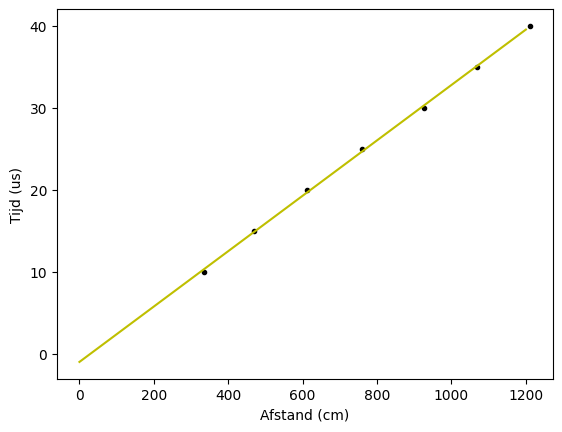

In [3]:
afstanden = np.array([10,15,20,25,30,35,40]) #cm
tijden = np.array([334,470,612,760,926,1068,1212]) #us #+-4 us

def linear_model(x,a,b):
    return x*a + b

val,cov = curve_fit(linear_model,tijden, afstanden)
a,b = val

x_fit = np.linspace(0, 1200 ,1000)
y_fit = linear_model(x_fit, *val)

plt.figure
plt.plot(tijden, afstanden, 'k.')
plt.plot(x_fit,y_fit,"y")
plt.xlabel("Afstand (cm)")
plt.ylabel("Tijd (us)")
plt.show

print(a,b)

## Opdracht 4: Test meting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  43.2
1   0  30   0  20  42.5
2   0  10   0  20  46.5
3  40   0  30   0  42.3
4  30   0  20   0  42.4
5  10   0  20   0  47.6


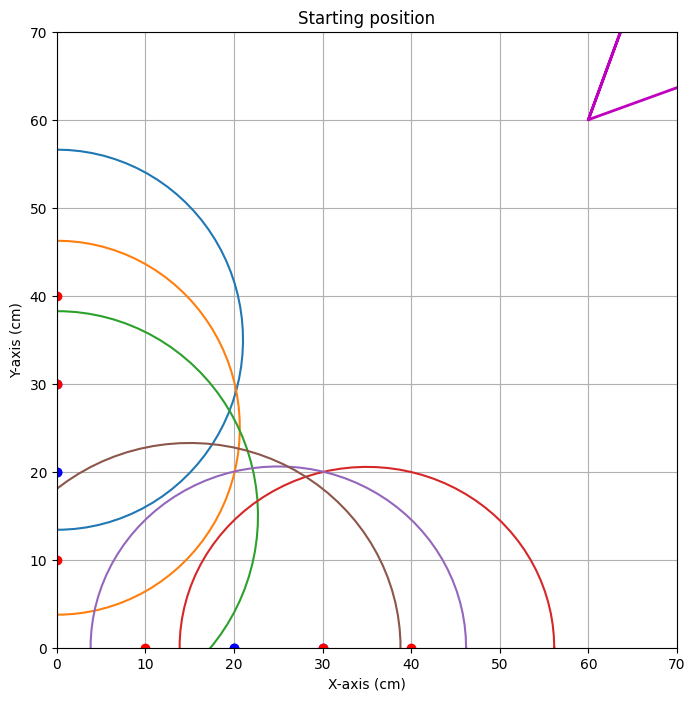


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=103.141


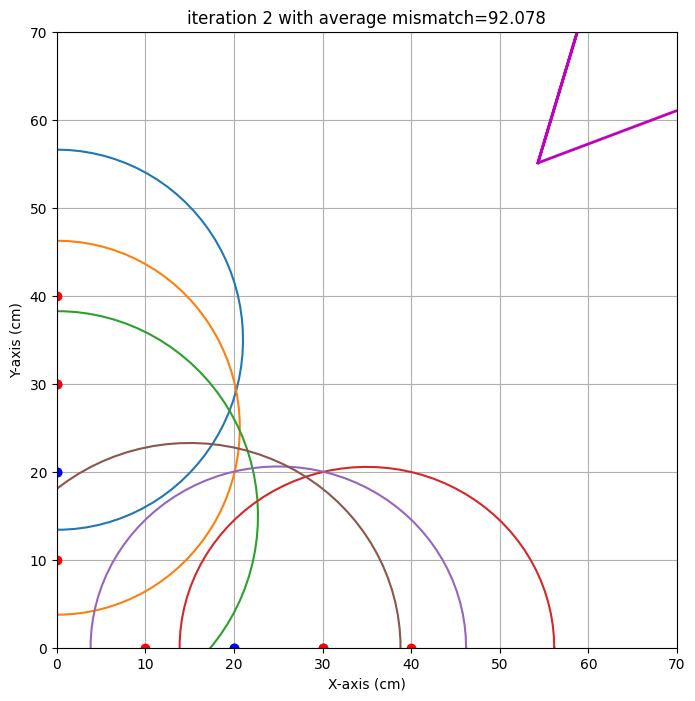

end iteration 2 with average mismatch=92.078


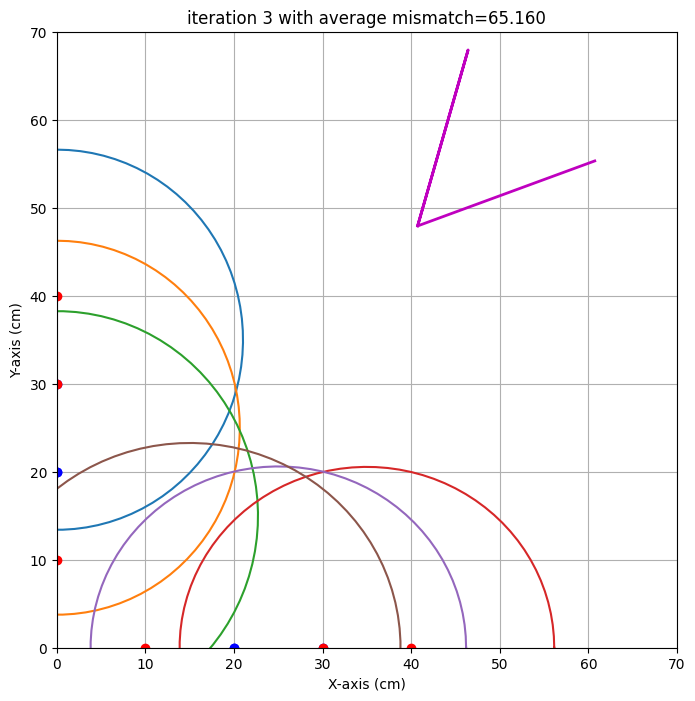

end iteration 3 with average mismatch=65.160


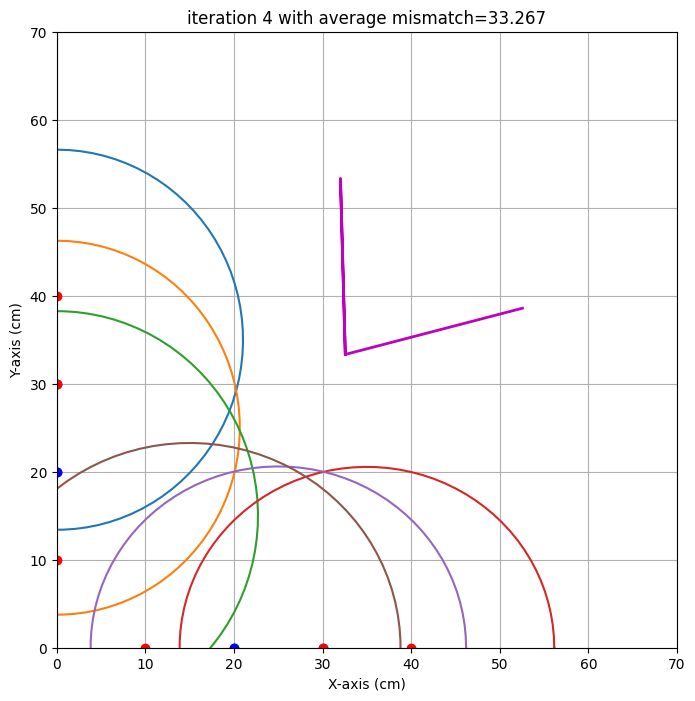

end iteration 4 with average mismatch=33.267


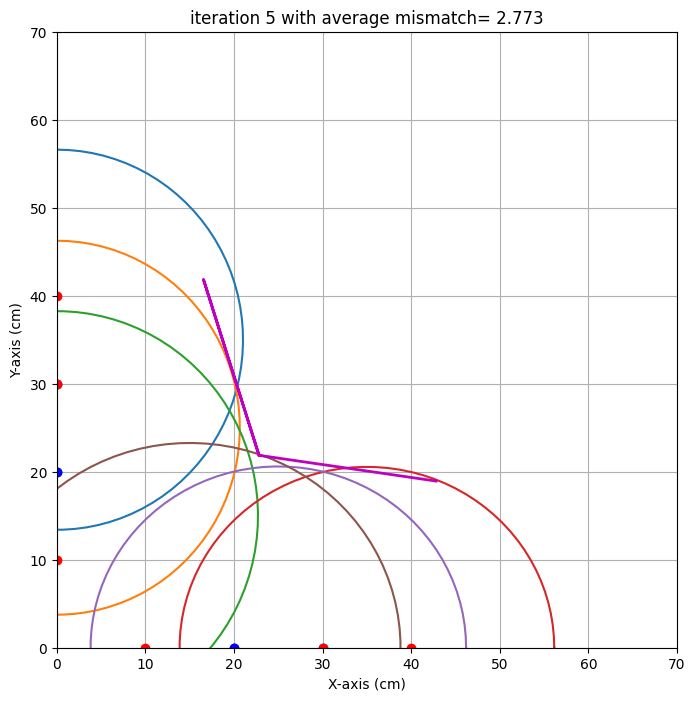

end iteration 5 with average mismatch= 2.773


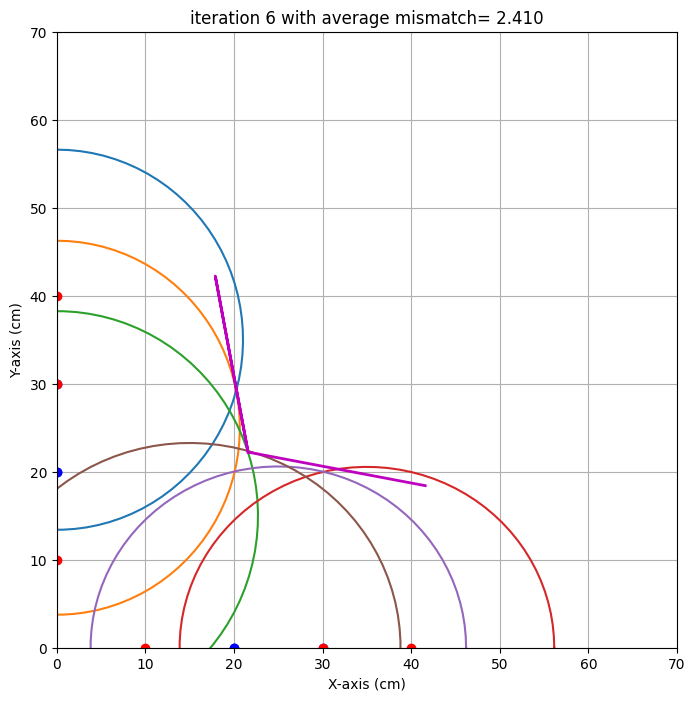

end iteration 6 with average mismatch= 2.410


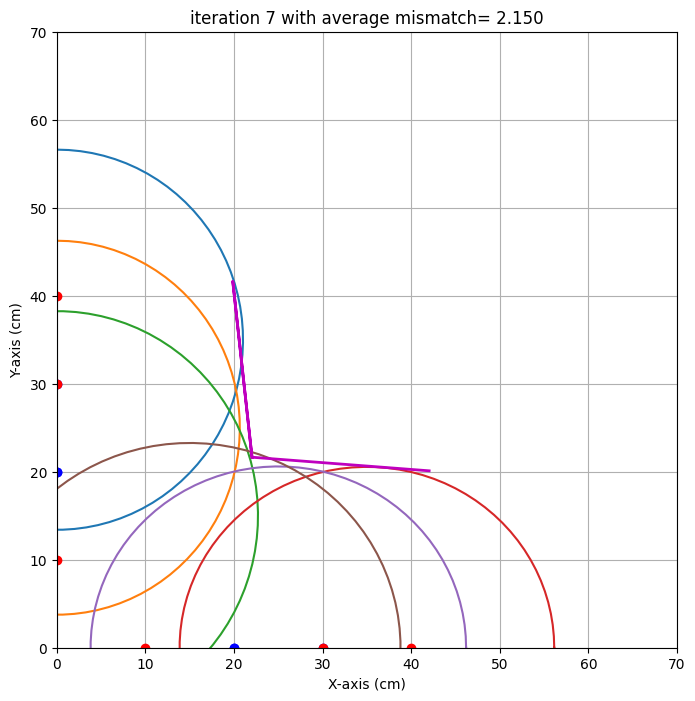

end iteration 7 with average mismatch= 2.150


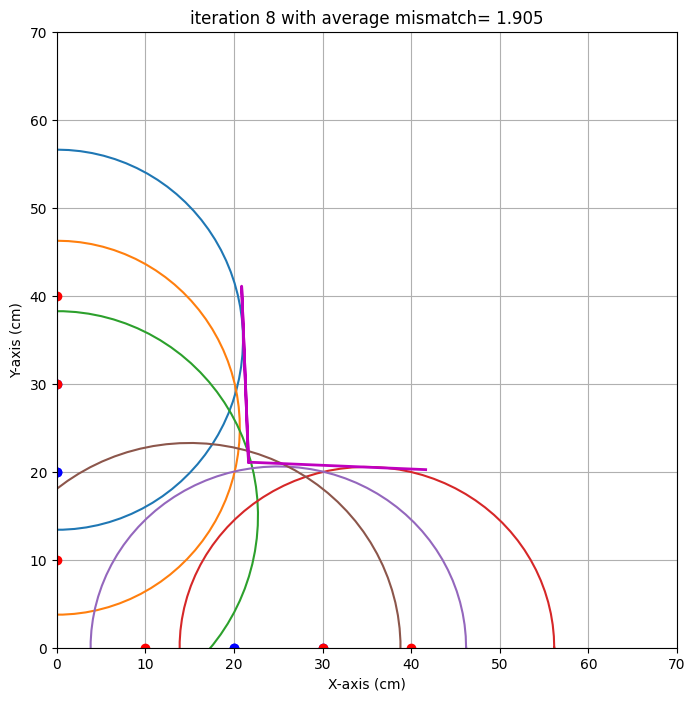

end iteration 8 with average mismatch= 1.905
end iteration 9 with average mismatch= 1.762
end iteration 10 with average mismatch= 1.738
end iteration 11 with average mismatch= 1.738
end iteration 12 with average mismatch= 1.738
end iteration 13 with average mismatch= 1.738
end iteration 14 with average mismatch= 1.738
end iteration 15 with average mismatch= 1.738
end iteration 16 with average mismatch= 1.738
end iteration 17 with average mismatch= 1.738
end iteration 18 with average mismatch= 1.738
end iteration 19 with average mismatch= 1.738
end iteration 20 with average mismatch= 1.738
end iteration 21 with average mismatch= 1.738
end iteration 22 with average mismatch= 1.738
end iteration 23 with average mismatch= 1.738
end iteration 24 with average mismatch= 1.738
end iteration 25 with average mismatch= 1.738
end iteration 26 with average mismatch= 1.738
end iteration 27 with average mismatch= 1.738
end iteration 28 with average mismatch= 1.738
end iteration 29 with average mismat

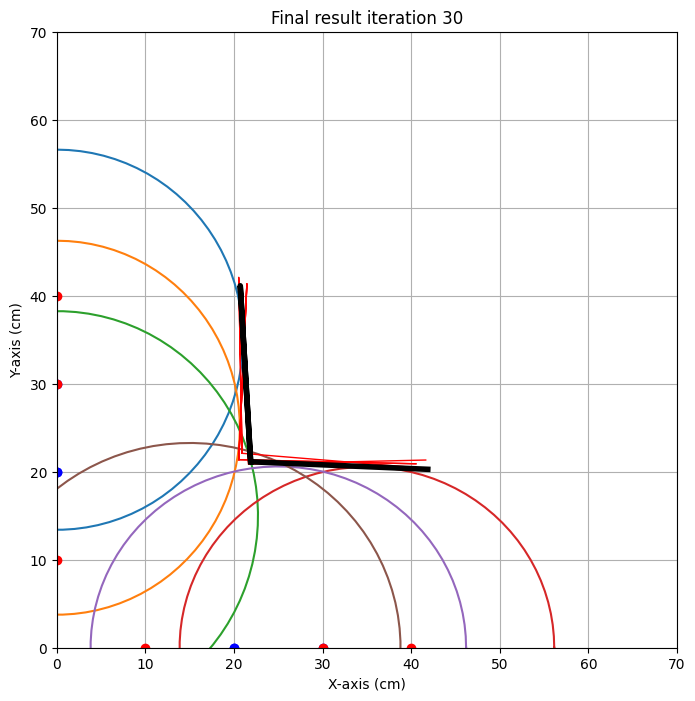

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.2],
    [0,30,0,20,42.5],
    [0,10,0,20,46.5],
    [40,0,30,0,42.3],
    [30,0,20,0,42.4],
    [10,0,20,0,47.6],
    #[10,0,0,10,180.3]    #deze meting is niet geldig
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.9 cm met een standaardafwijking van 1.3 cm 
y0: 21.1 cm met een standaardafwijking van 1.0 cm 
alpha: -2.5 graden met een standaardafwijking van 3.8 graad 
beta: -3.4 graden met een standaardafwijking van 6.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Avnay]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme_avnay_1.jpeg" width="400">
<img src="algoritme_avnay_2.jpeg" width="400">

#### algoritme [Aren]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algoritme_aren_2.jpeg" width="400">

#### algoritme [Koen]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algoritme_koen_1.jpeg" width="400">
<img src="algoritme_koen_2.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets1 = {'x0': 26,
           'y0': 37,
           'alpha' : 32,
           'beta' : 8,
          }
           
targets2 = {'x0': 39,
           'y0': 25,
           'alpha' : 22 ,
           'beta' : 6,
          }         

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Avnay' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,60,64.5],
    [0,40,0,50,61.9],
    #[0,30,0,40,ongeldig]
    #[50,0,60,0,ongeldig]
    [40,0,50,0,76.3],
    [30,0,40,0,65.1]
    #[20,0,30,0,ongeldig]
    ]),
        'Koen' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,60,0,40,83.0],
    [0,40,0,20,81.3],
    [60,0,40,0,62.2],
    #[40,0,20,0,ongeldig]
    [0,45,0,55,78.5],
    [0,25,0,35,75.0],
    [45,0,55,0,58.6]
     ])
      }

## Opdracht 7: Evaluatie.

Avnay
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  60  64.5
1   0  40   0  50  61.9
2  40   0  50   0  76.3
3  30   0  40   0  65.1


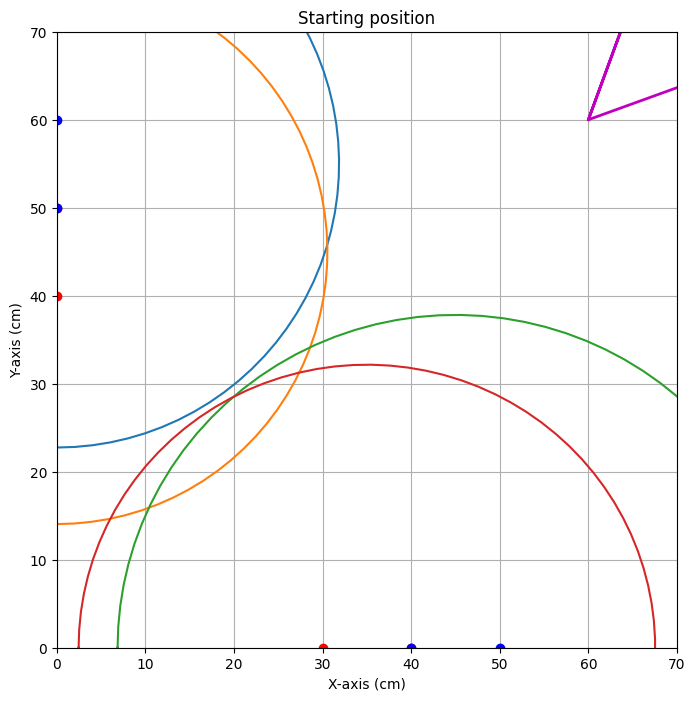


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.966


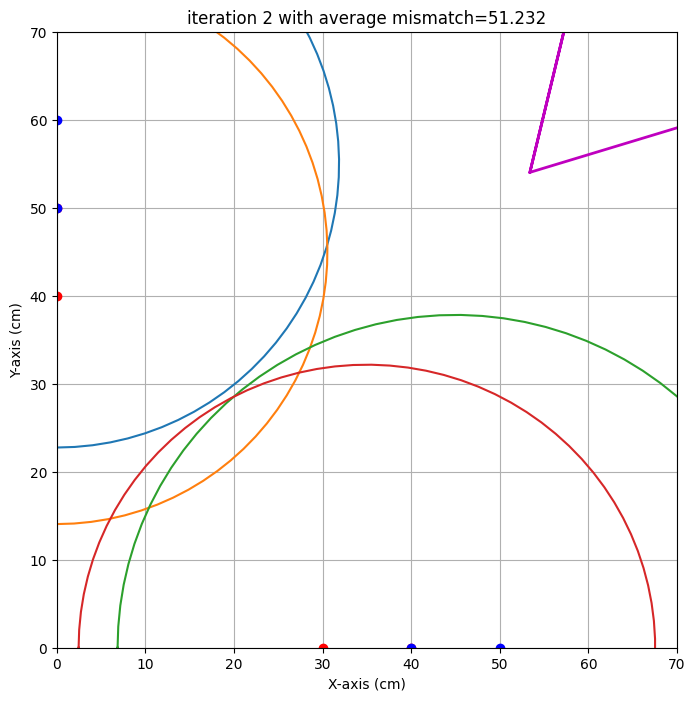

end iteration 2 with average mismatch=51.232


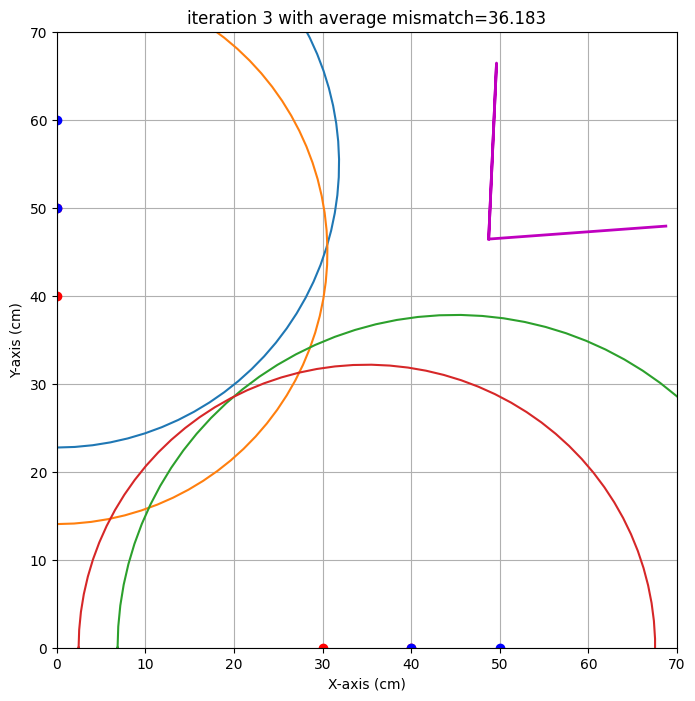

end iteration 3 with average mismatch=36.183


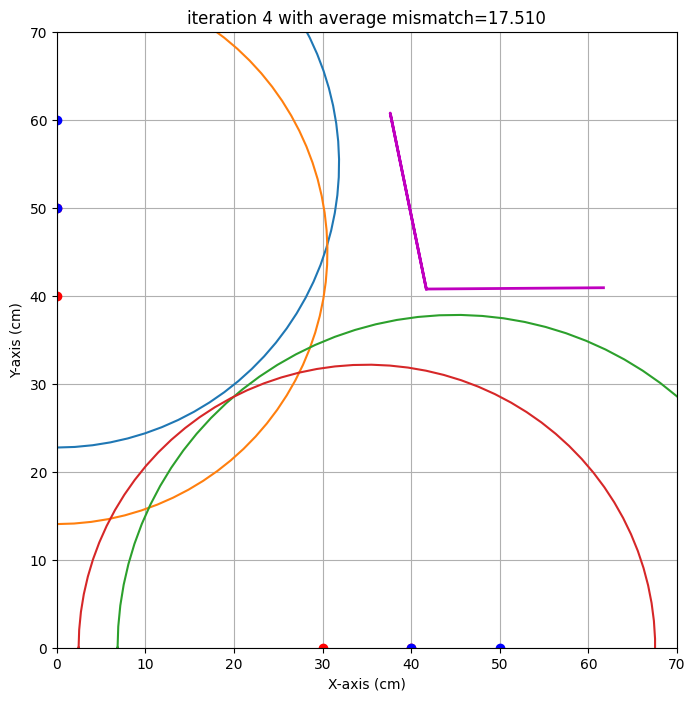

end iteration 4 with average mismatch=17.510


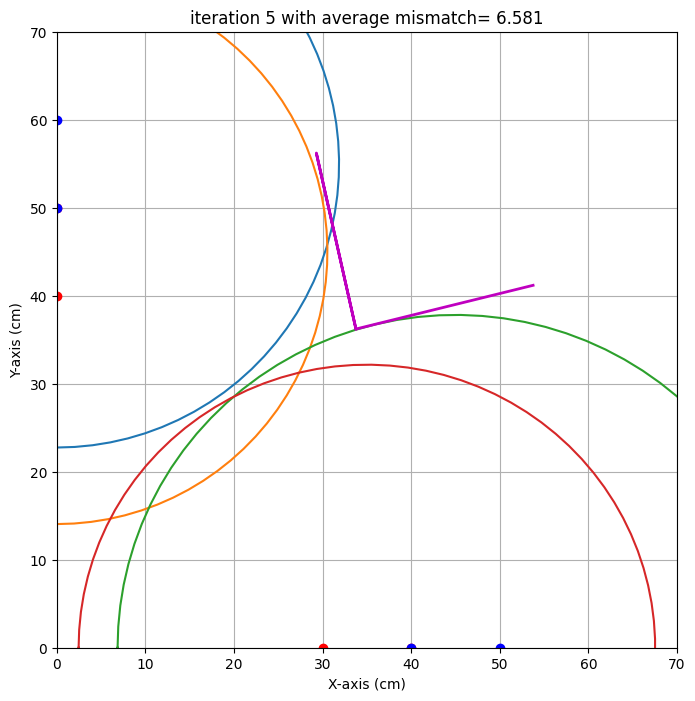

end iteration 5 with average mismatch= 6.581
end iteration 6 with average mismatch= 6.074


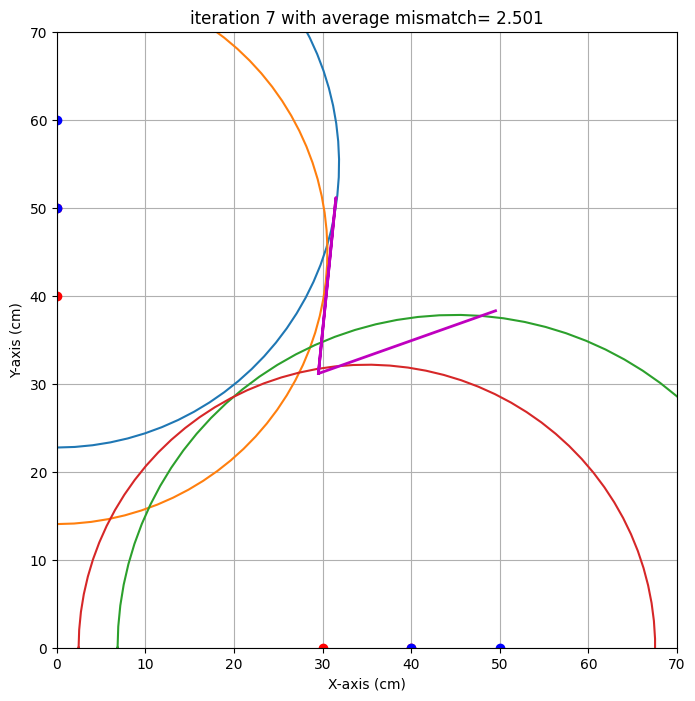

end iteration 7 with average mismatch= 2.501
end iteration 8 with average mismatch= 2.262
end iteration 9 with average mismatch= 2.075
end iteration 10 with average mismatch= 1.881
end iteration 11 with average mismatch= 1.881
end iteration 12 with average mismatch= 1.881
end iteration 13 with average mismatch= 1.881
end iteration 14 with average mismatch= 1.881
end iteration 15 with average mismatch= 1.881
end iteration 16 with average mismatch= 1.881
end iteration 17 with average mismatch= 1.881
end iteration 18 with average mismatch= 1.881
end iteration 19 with average mismatch= 1.881
end iteration 20 with average mismatch= 1.881
end iteration 21 with average mismatch= 1.881
end iteration 22 with average mismatch= 1.797
end iteration 23 with average mismatch= 1.794
end iteration 24 with average mismatch= 1.793
end iteration 25 with average mismatch= 1.793
end iteration 26 with average mismatch= 1.793
end iteration 27 with average mismatch= 1.793
end iteration 28 with average mismatc

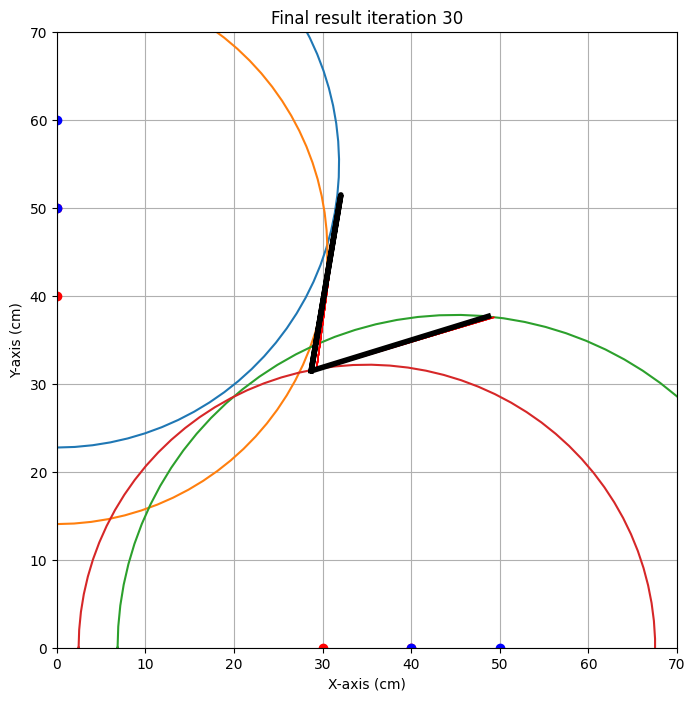

{'alpha': np.float64(17.22004451166566), 'alpha_eps': np.float64(0.5111413704577039), 'beta': np.float64(9.520317831221876), 'beta_eps': np.float64(1.9507283641232096), 'x0': np.float64(28.705802729225272), 'x0_eps': np.float64(0.5942181602372933), 'y0': np.float64(31.458237922444702), 'y0_eps': np.float64(0.06777788544865615)}
Koen
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  40  83.0
1   0  40   0  20  81.3
2  60   0  40   0  62.2
3   0  45   0  55  78.5
4   0  25   0  35  75.0
5  45   0  55   0  58.6


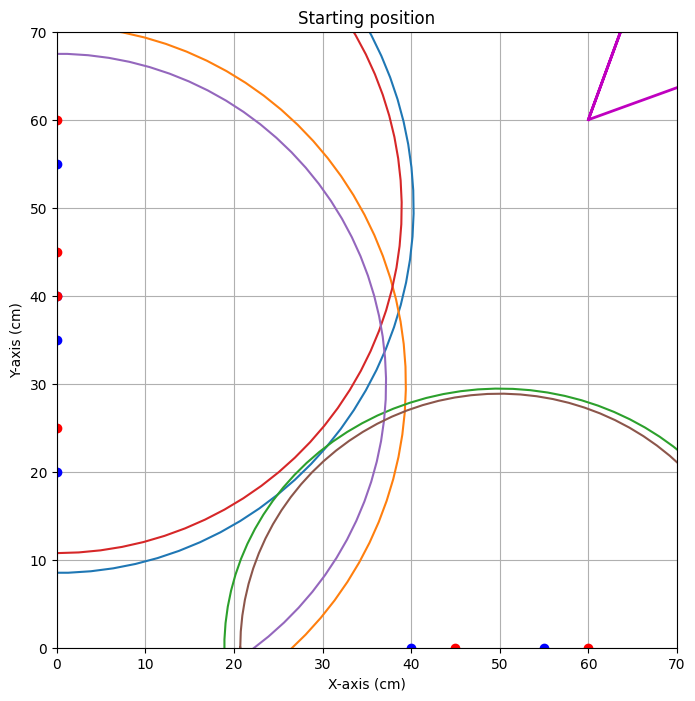


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.527


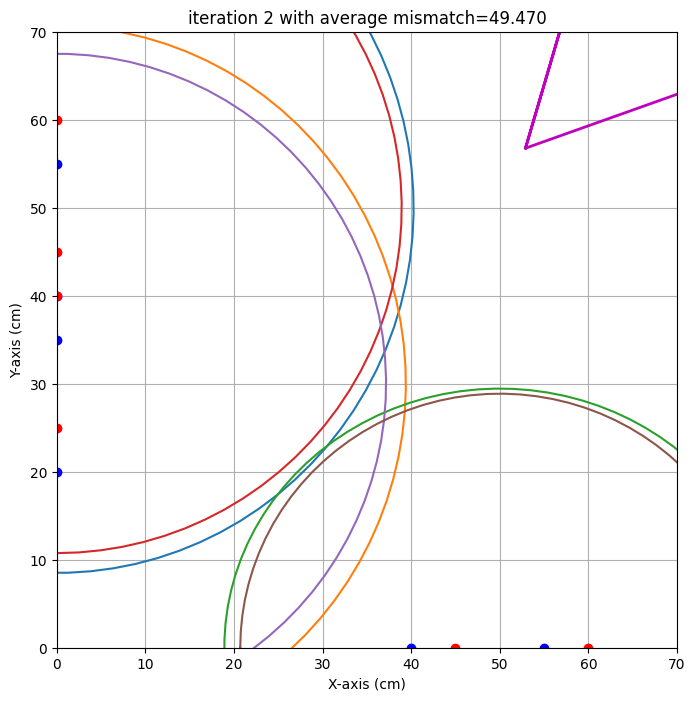

end iteration 2 with average mismatch=49.470


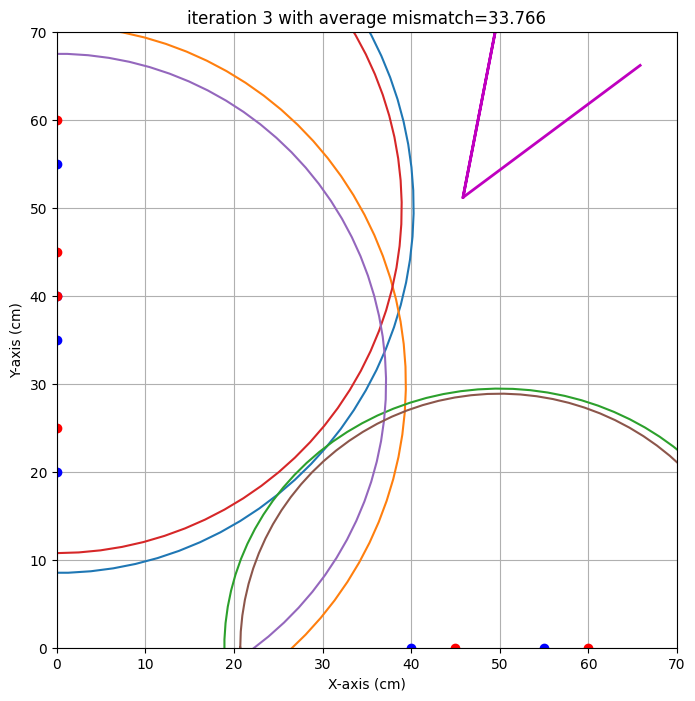

end iteration 3 with average mismatch=33.766


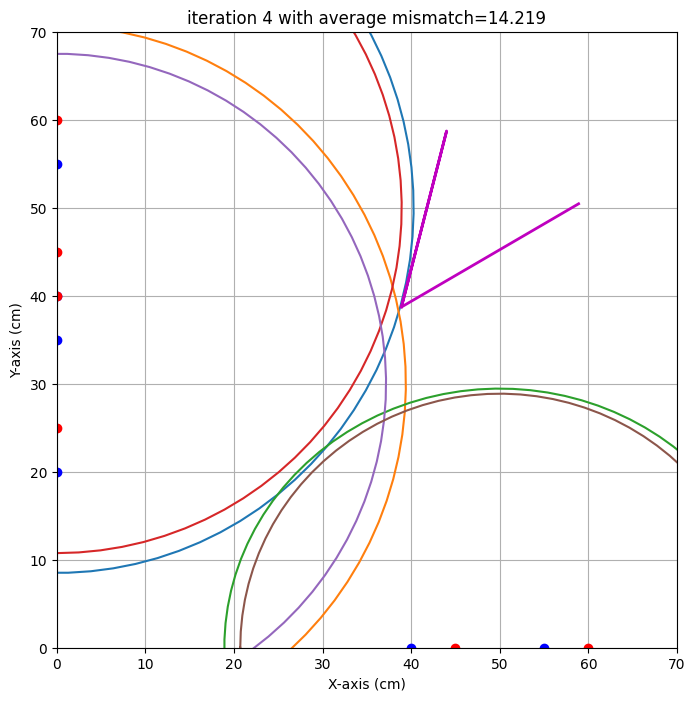

end iteration 4 with average mismatch=14.219


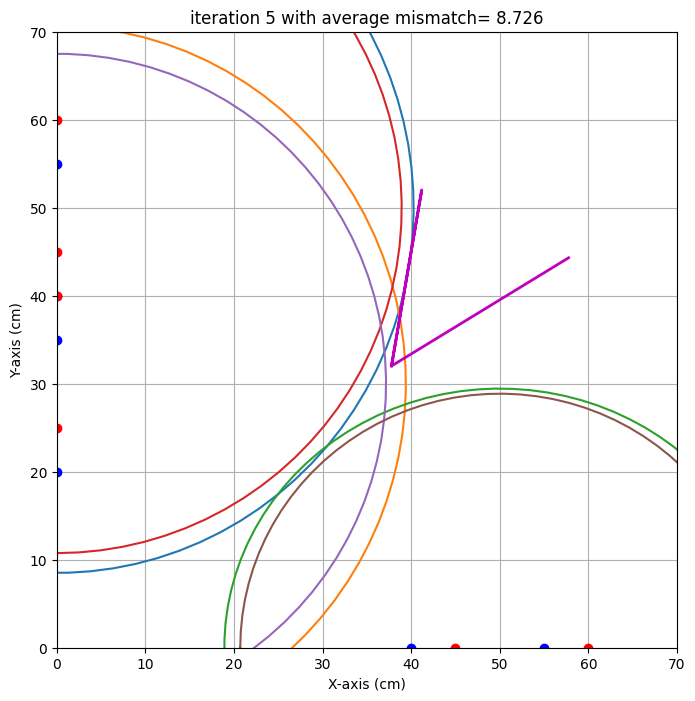

end iteration 5 with average mismatch= 8.726


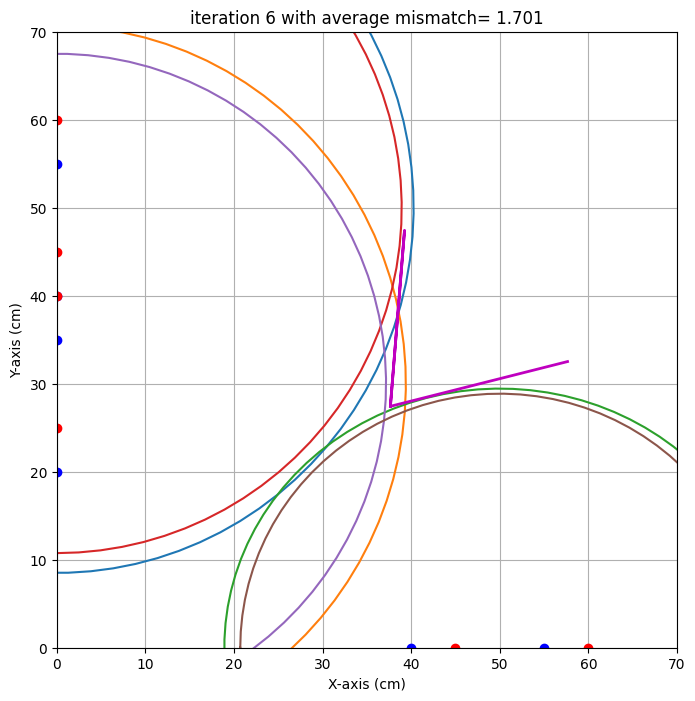

end iteration 6 with average mismatch= 1.701
end iteration 7 with average mismatch= 1.640
end iteration 8 with average mismatch= 1.636
end iteration 9 with average mismatch= 1.635
end iteration 10 with average mismatch= 1.634
end iteration 11 with average mismatch= 1.634
end iteration 12 with average mismatch= 1.634
end iteration 13 with average mismatch= 1.567
end iteration 14 with average mismatch= 1.556
end iteration 15 with average mismatch= 1.525
end iteration 16 with average mismatch= 1.519
end iteration 17 with average mismatch= 1.518
end iteration 18 with average mismatch= 1.518
end iteration 19 with average mismatch= 1.518
end iteration 20 with average mismatch= 1.518
end iteration 21 with average mismatch= 1.518
end iteration 22 with average mismatch= 1.518
end iteration 23 with average mismatch= 1.518
end iteration 24 with average mismatch= 1.518
end iteration 25 with average mismatch= 1.518
end iteration 26 with average mismatch= 1.518
end iteration 27 with average mismatch

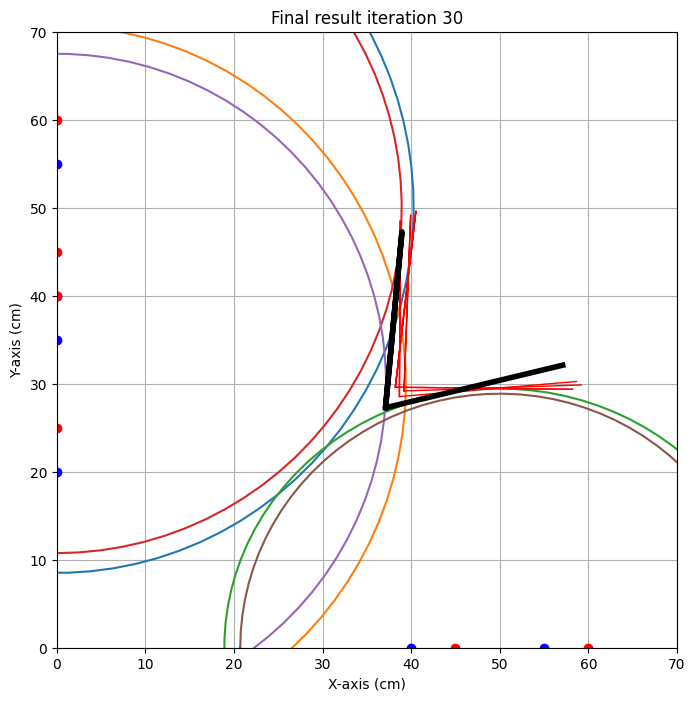

{'alpha': np.float64(13.593221865148225), 'alpha_eps': np.float64(14.2874874734731), 'beta': np.float64(5.3104800996573145), 'beta_eps': np.float64(5.032707929651766), 'x0': np.float64(37.098531608720606), 'x0_eps': np.float64(2.0877873678615586), 'y0': np.float64(27.268239029439094), 'y0_eps': np.float64(2.3389839368031424)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName[0:5],
                     x0Target=targets1['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets1['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets1['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets1['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))
    print(txt.format(naam = studentName[5:9],
                     x0Target=targets2['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets2['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets2['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets2['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))
    
    

Avnay 
x0 target is : 26.0. Gevonden waarde: 28.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 37.0. Gevonden waarde: 31.5 cm met een standaardafwijking van 0.1 cm 
alpha target is : 32.0. Gevonden waarde: 17.2 graden met een standaardafwijking van 0.5 graad 
beta target is : 8.0. Gevonden waarde: 9.5 graden met een standaardafwijking van 2.0 graad 

 
x0 target is : 39.0. Gevonden waarde: 28.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 25.0. Gevonden waarde: 31.5 cm met een standaardafwijking van 0.1 cm 
alpha target is : 22.0. Gevonden waarde: 17.2 graden met een standaardafwijking van 0.5 graad 
beta target is : 6.0. Gevonden waarde: 9.5 graden met een standaardafwijking van 2.0 graad 

Koen 
x0 target is : 26.0. Gevonden waarde: 37.1 cm met een standaardafwijking van 2.1 cm 
y0 target is : 37.0. Gevonden waarde: 27.3 cm met een standaardafwijking van 2.3 cm 
alpha target is : 32.0. Gevonden waarde: 13.6 graden met een standaardafwijking van 14.3 graad 
bet

Alleen de eerste en laatste van deze vier bovenstaande tekstbalkjes moet naar gekeken worden.

## Opdracht 8: Iteratie1+.15:45
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie_kloppend.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  60   68.5
1  40   0  60   0  100.7
2  45   0  55   0   99.8
3   0  45   0  55   64.2
4   0  55   0  65   64.3
5   0  60   0  70   66.1
6  35   0  45   0  122.0
7  50   0  60   0  106.8


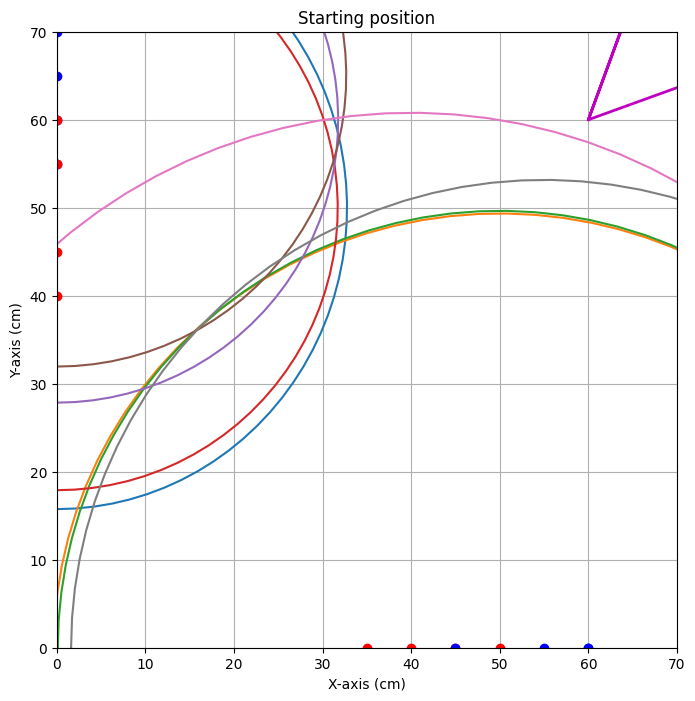


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=41.533


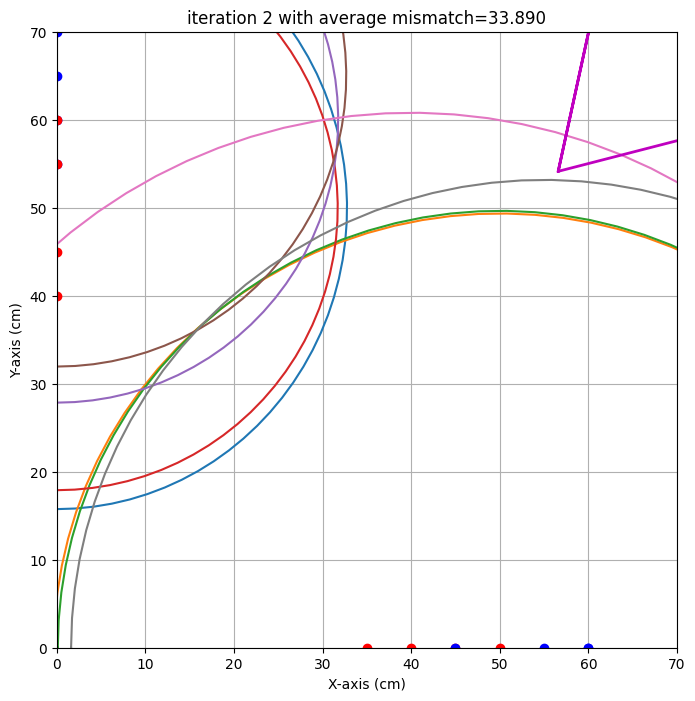

end iteration 2 with average mismatch=33.890


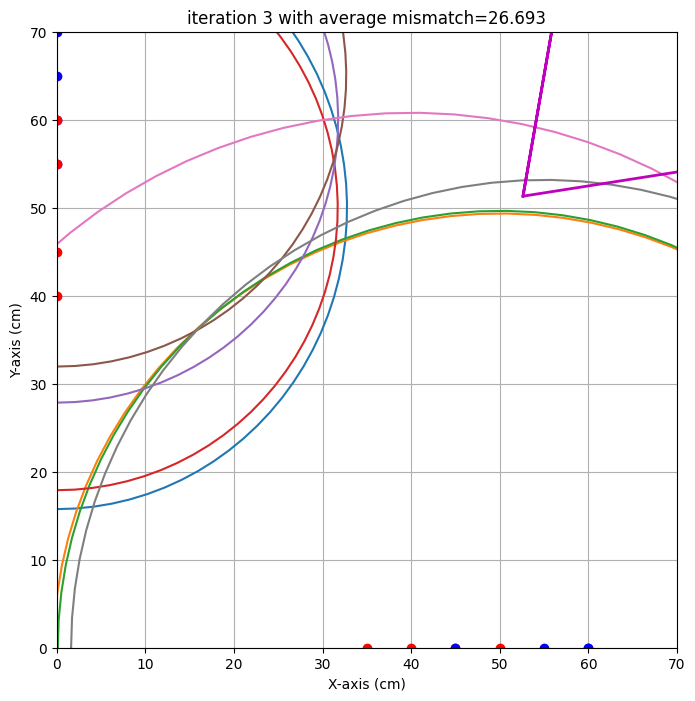

end iteration 3 with average mismatch=26.693


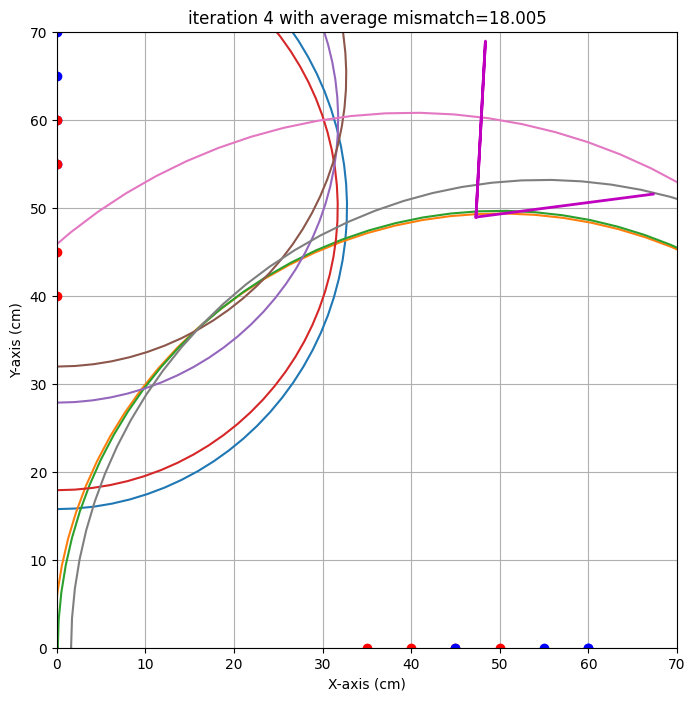

end iteration 4 with average mismatch=18.005


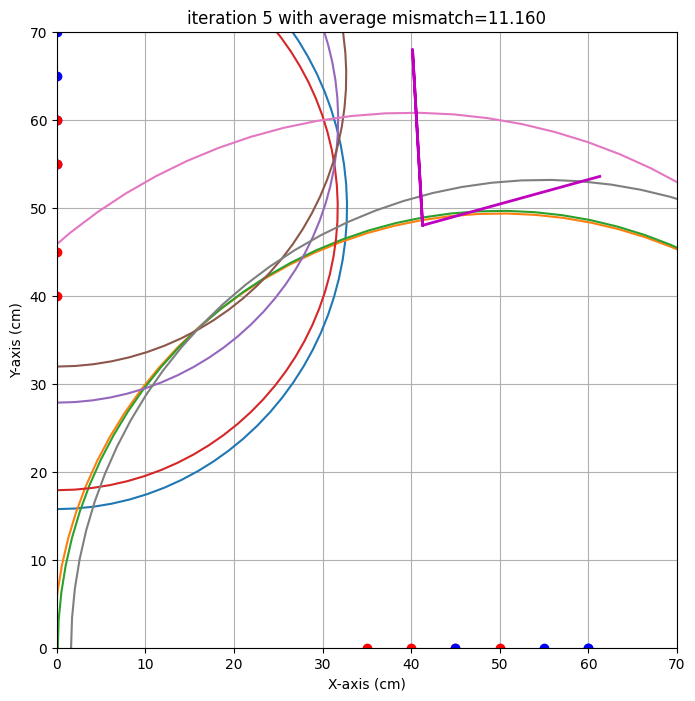

end iteration 5 with average mismatch=11.160


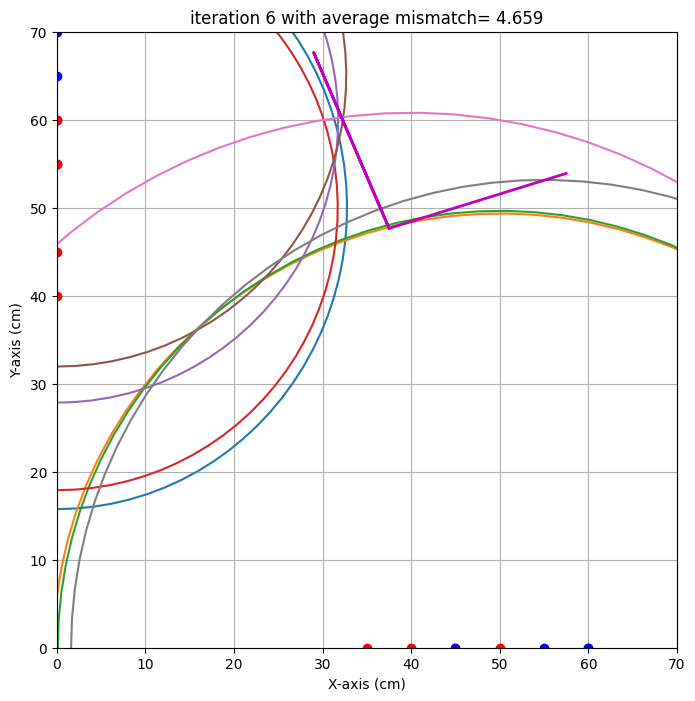

end iteration 6 with average mismatch= 4.659


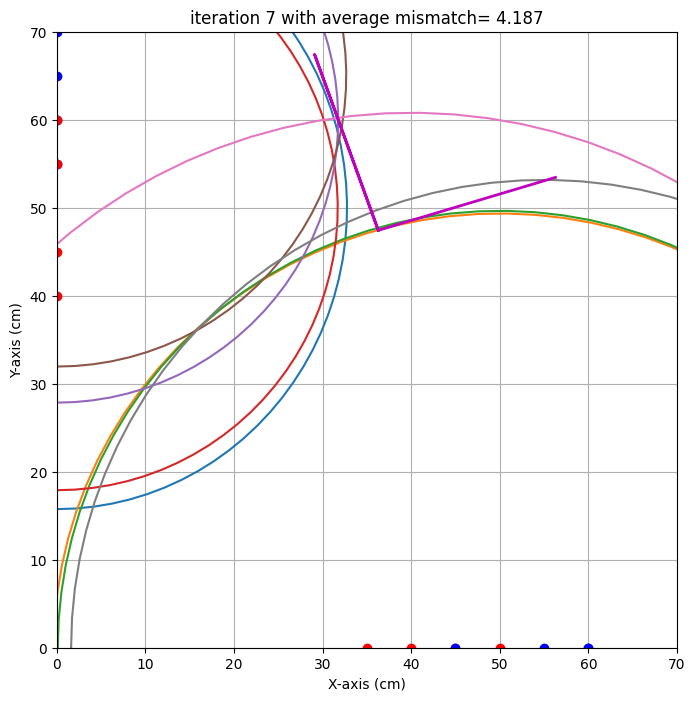

end iteration 7 with average mismatch= 4.187
end iteration 8 with average mismatch= 4.083


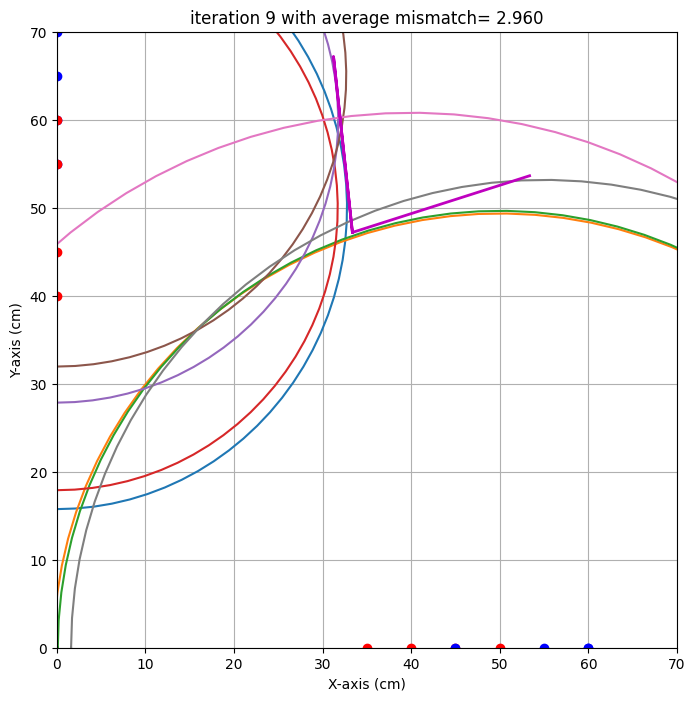

end iteration 9 with average mismatch= 2.960
end iteration 10 with average mismatch= 2.960
end iteration 11 with average mismatch= 2.797
end iteration 12 with average mismatch= 2.699
end iteration 13 with average mismatch= 2.699
end iteration 14 with average mismatch= 2.673
end iteration 15 with average mismatch= 2.673
end iteration 16 with average mismatch= 2.673
end iteration 17 with average mismatch= 2.575
end iteration 18 with average mismatch= 2.564
end iteration 19 with average mismatch= 2.564
end iteration 20 with average mismatch= 2.564
end iteration 21 with average mismatch= 2.564
end iteration 22 with average mismatch= 2.564
end iteration 23 with average mismatch= 2.564
end iteration 24 with average mismatch= 2.564
end iteration 25 with average mismatch= 2.564
end iteration 26 with average mismatch= 2.564
end iteration 27 with average mismatch= 2.564
end iteration 28 with average mismatch= 2.564
end iteration 29 with average mismatch= 2.564
Last iteration, also determine unce

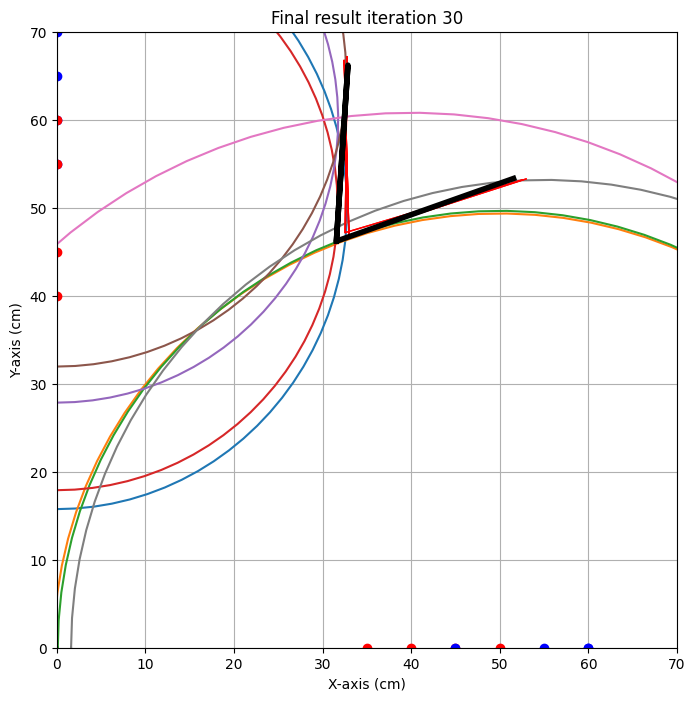

{'alpha': np.float64(19.608712014610386), 'alpha_eps': np.float64(2.9180139868062334), 'beta': np.float64(3.731420596105759), 'beta_eps': np.float64(5.281480212269253), 'x0': np.float64(31.55351673659347), 'x0_eps': np.float64(1.420830869940911), 'y0': np.float64(46.197348611572934), 'y0_eps': np.float64(0.979418874150042)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  20   0  40  91.5
1  40   0  60   0  46.9
2   0  35   0  45  92.1
3   0  25   0  35  89.8
4  55   0  65   0  43.6
5  45   0  55   0  39.4
6  60   0  70   0  44.7
7   0  35   0  41  92.3


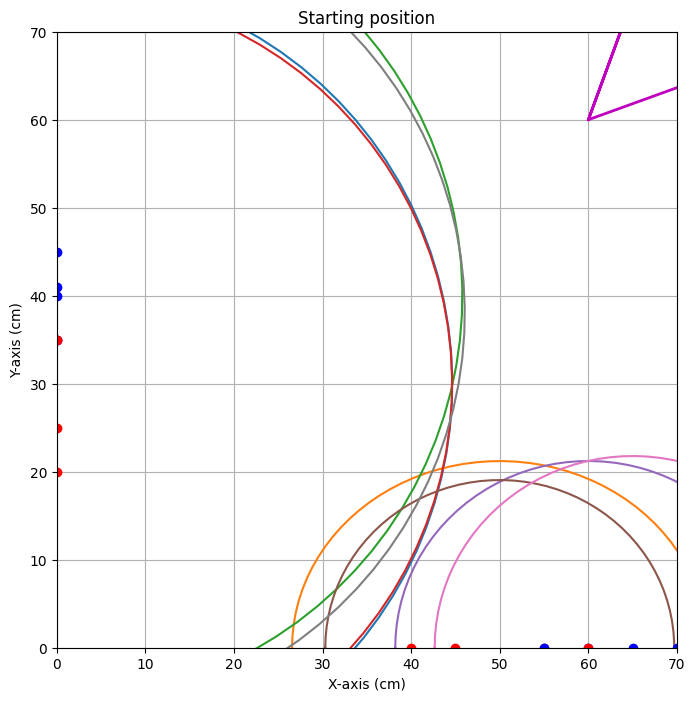


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=65.843


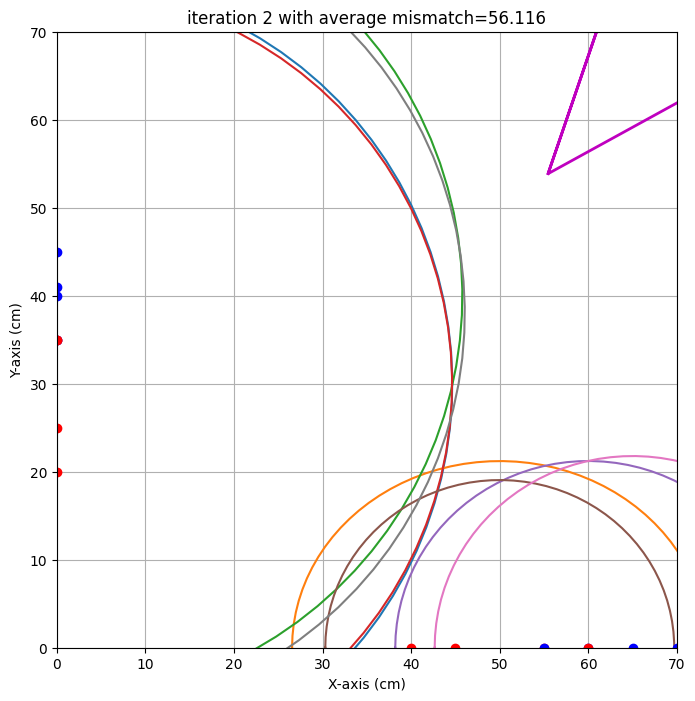

end iteration 2 with average mismatch=56.116


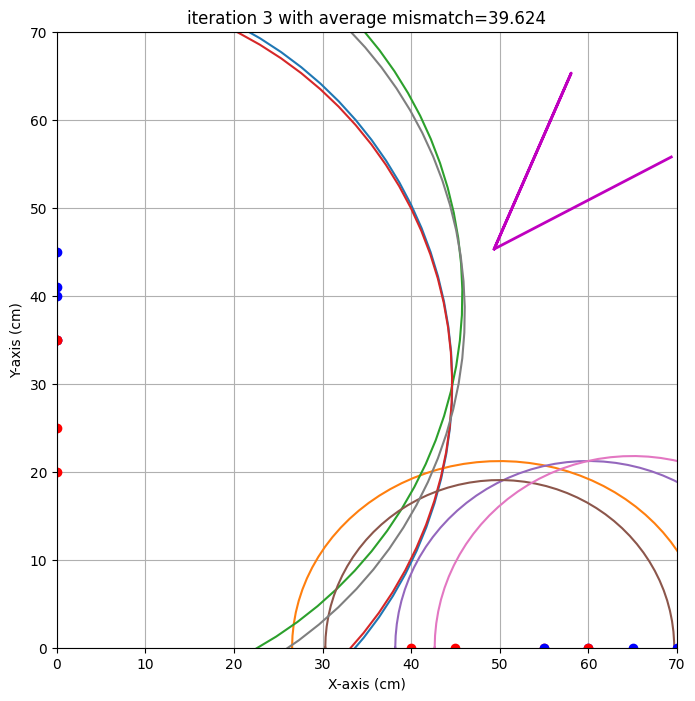

end iteration 3 with average mismatch=39.624


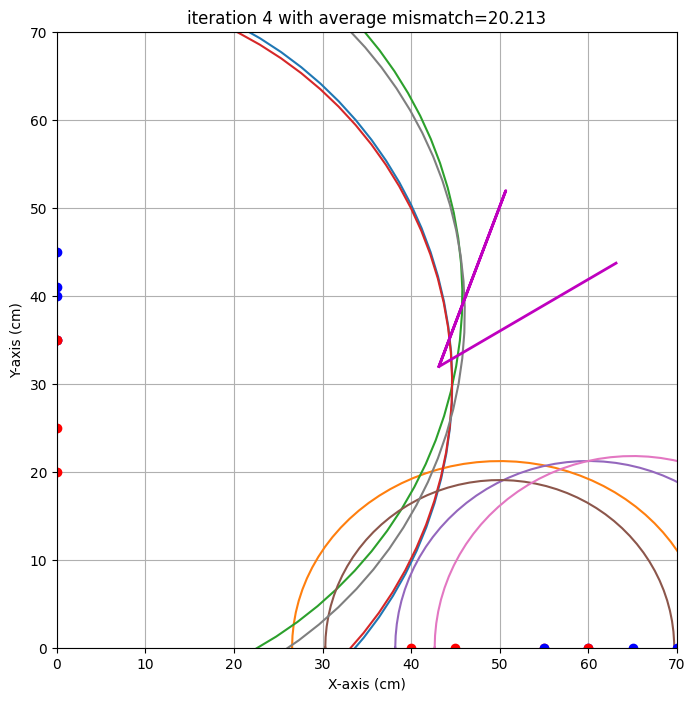

end iteration 4 with average mismatch=20.213


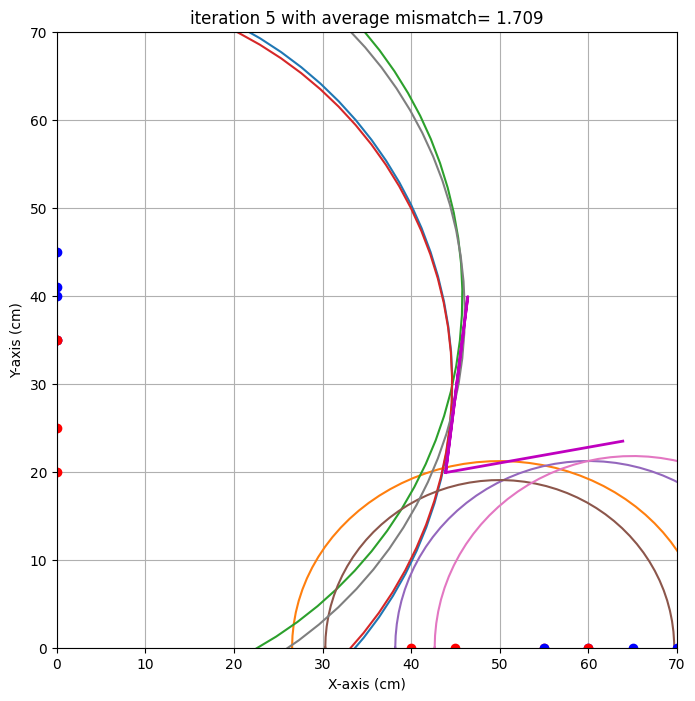

end iteration 5 with average mismatch= 1.709


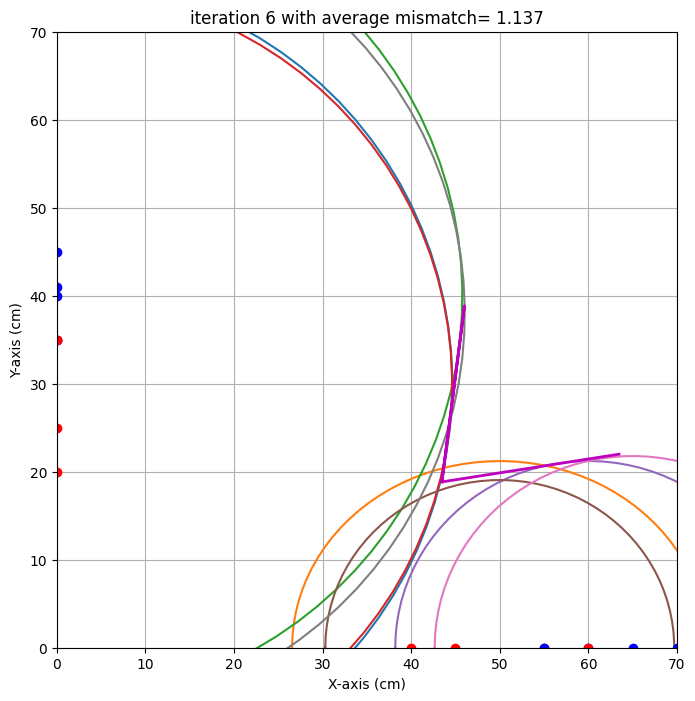

end iteration 6 with average mismatch= 1.137
end iteration 7 with average mismatch= 1.134


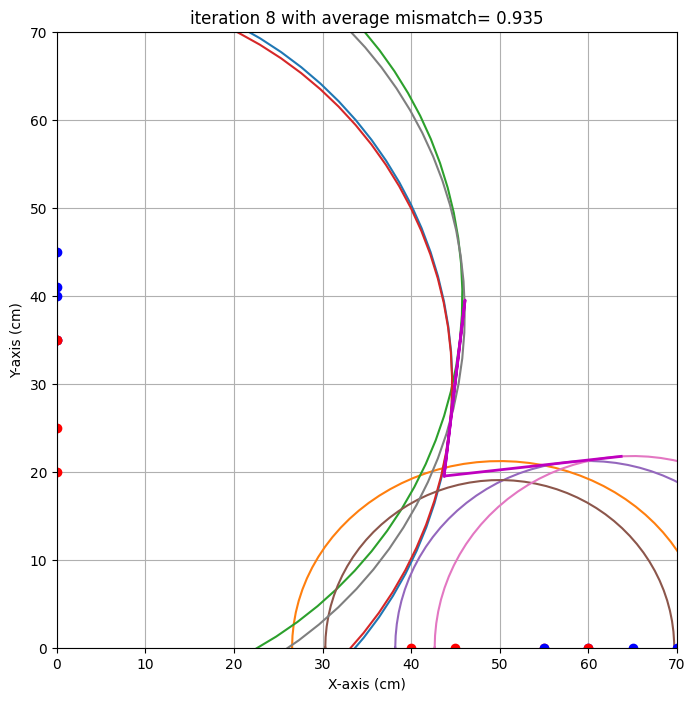

end iteration 8 with average mismatch= 0.935
end iteration 9 with average mismatch= 0.931
end iteration 10 with average mismatch= 0.930
end iteration 11 with average mismatch= 0.930
end iteration 12 with average mismatch= 0.929
end iteration 13 with average mismatch= 0.929
end iteration 14 with average mismatch= 0.929
end iteration 15 with average mismatch= 0.929
end iteration 16 with average mismatch= 0.929
end iteration 17 with average mismatch= 0.929
end iteration 18 with average mismatch= 0.929
end iteration 19 with average mismatch= 0.929
end iteration 20 with average mismatch= 0.929
end iteration 21 with average mismatch= 0.929
end iteration 22 with average mismatch= 0.929
end iteration 23 with average mismatch= 0.929
end iteration 24 with average mismatch= 0.929
end iteration 25 with average mismatch= 0.929
end iteration 26 with average mismatch= 0.929
end iteration 27 with average mismatch= 0.929
end iteration 28 with average mismatch= 0.929
end iteration 29 with average mismat

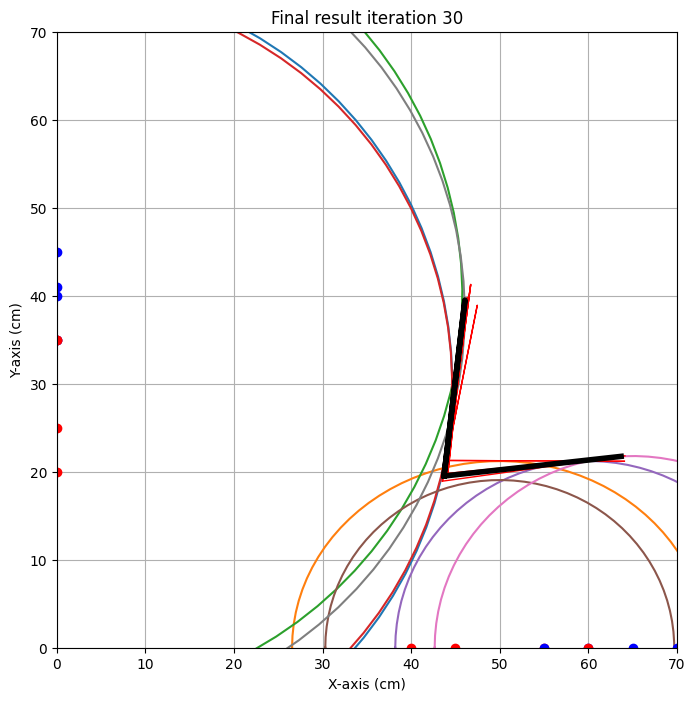

{'alpha': np.float64(6.377461972753195), 'alpha_eps': np.float64(6.634558448158908), 'beta': np.float64(6.754643354285235), 'beta_eps': np.float64(4.4086002000427955), 'x0': np.float64(43.70170158714137), 'x0_eps': np.float64(0.4335275230898219), 'y0': np.float64(19.508668715734494), 'y0_eps': np.float64(1.7704030189071283)}
locatie 1 
x0 target is : 30.0. Gevonden waarde: 31.6 cm met een standaardafwijking van 1.4 cm 
y0 target is : 46.0. Gevonden waarde: 46.2 cm met een standaardafwijking van 1.0 cm 
alpha target is : 30.0. Gevonden waarde: 19.6 graden met een standaardafwijking van 2.9 graad 
beta target is : 10.0. Gevonden waarde: 3.7 graden met een standaardafwijking van 5.3 graad 

locatie 2 
x0 target is : 44.0. Gevonden waarde: 43.7 cm met een standaardafwijking van 0.4 cm 
y0 target is : 16.0. Gevonden waarde: 19.5 cm met een standaardafwijking van 1.8 cm 
alpha target is : 14.0. Gevonden waarde: 6.4 graden met een standaardafwijking van 6.6 graad 
beta target is : 10.0. Gevon

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':30,
                    'y0':46,
                    'alpha' : 30,
                    'beta' : 10},
           'locatie 2':{'x0':44,
                    'y0':16,
                    'alpha' :14,
                    'beta' : 10}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,60,68.5],
    #[0,20,0,40,ongeldig],
    [40,0,60,0,100.7],
    #[20,0,40,0,ongeldig],
    [45,0,55,0,99.8],
    #[35,0,45,0,ongeldig],
    [0,45,0,55,64.2],
    [0,55,0,65,64.3],
    [0,60,0,70,66.1],
    [35,0,45,0,122.0],
    [50,0,60,0,106.8],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,20,0,40,91.5],
    [40,0,60,0,46.9],
    [0,35,0,45,92.1],
    [0,25,0,35,89.8],
    [55,0,65,0,43.6],
    [45,0,55,0,39.4],
    [60,0,70,0,44.7],
    [0,35,0,41,92.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  60  62.2
1   0  20   0  40  62.0
2  20   0  40   0  55.0
3   0  40   0  50  58.4
4   0  30   0  40  59.0
5  30   0  40   0  48.3
6  20   0  30   0  52.7


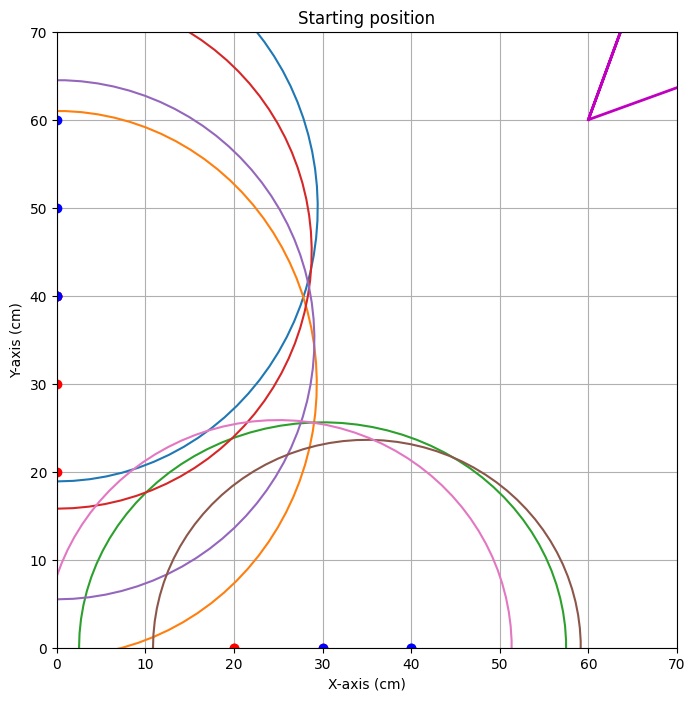


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=80.576


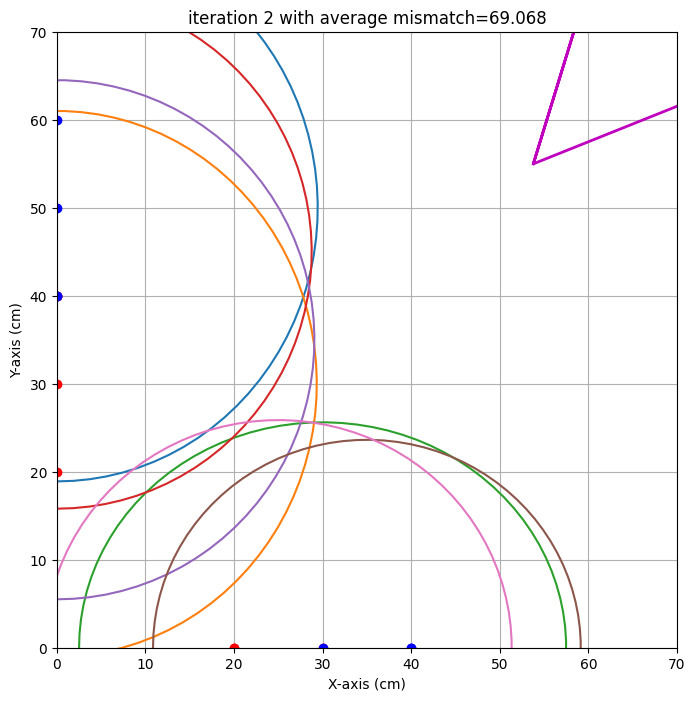

end iteration 2 with average mismatch=69.068


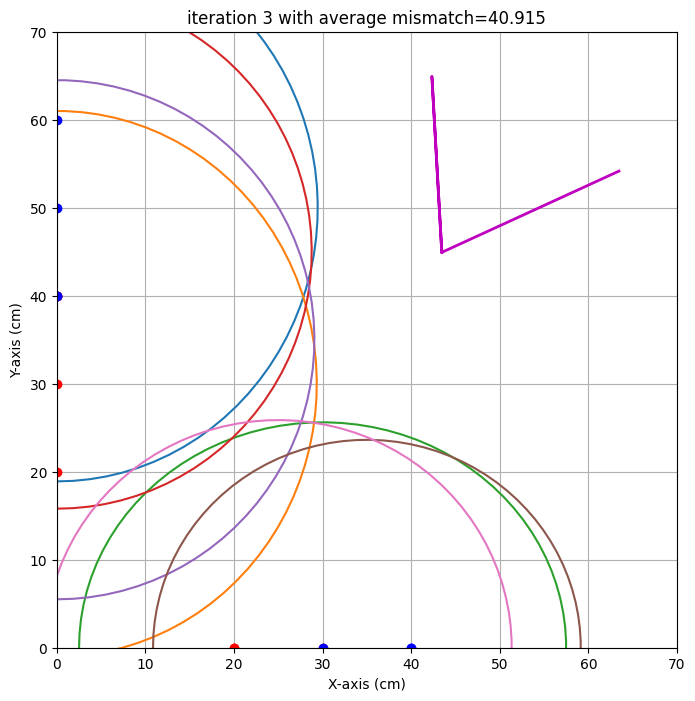

end iteration 3 with average mismatch=40.915


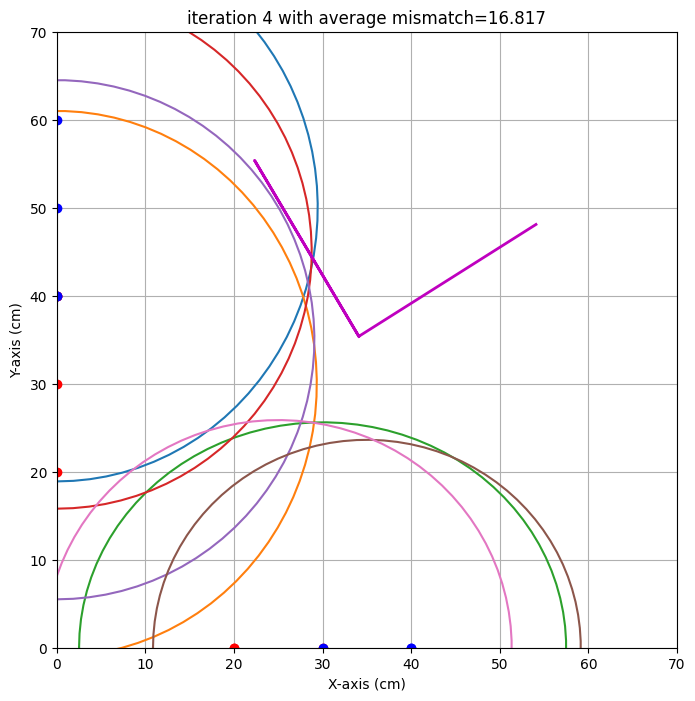

end iteration 4 with average mismatch=16.817


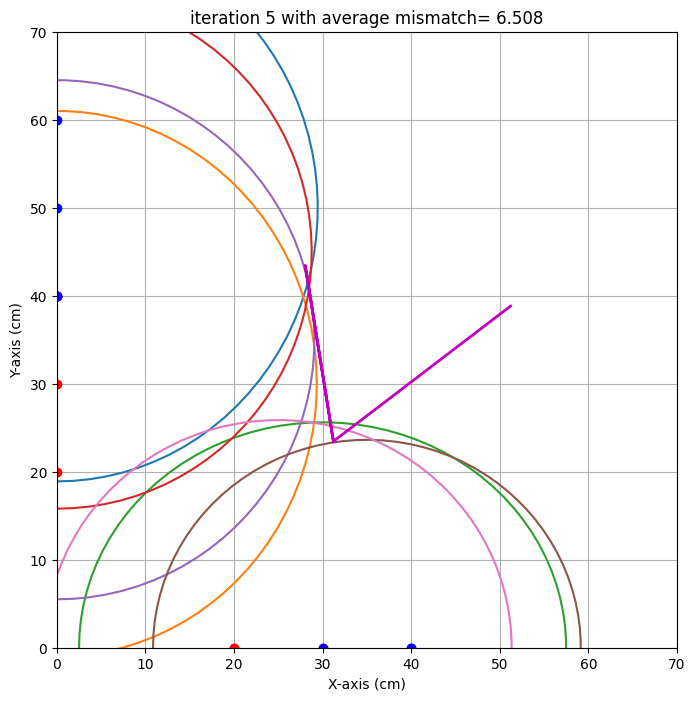

end iteration 5 with average mismatch= 6.508


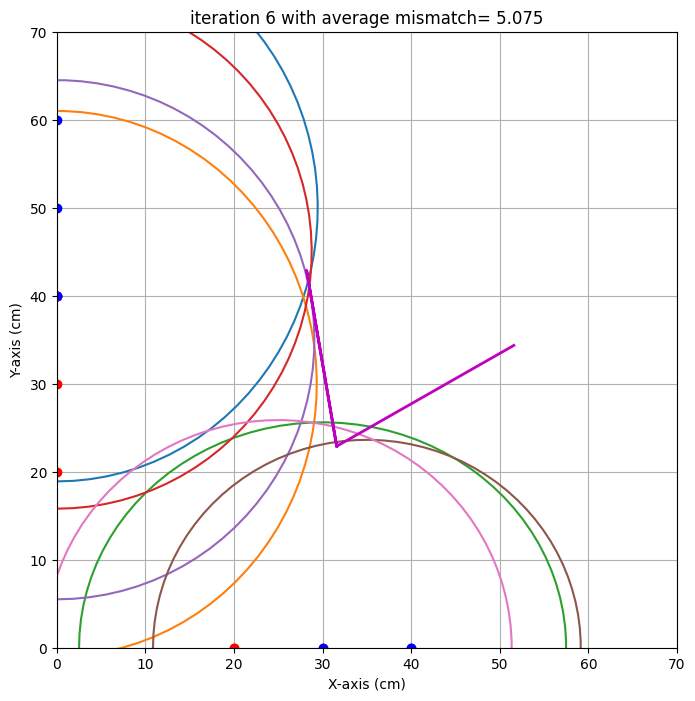

end iteration 6 with average mismatch= 5.075


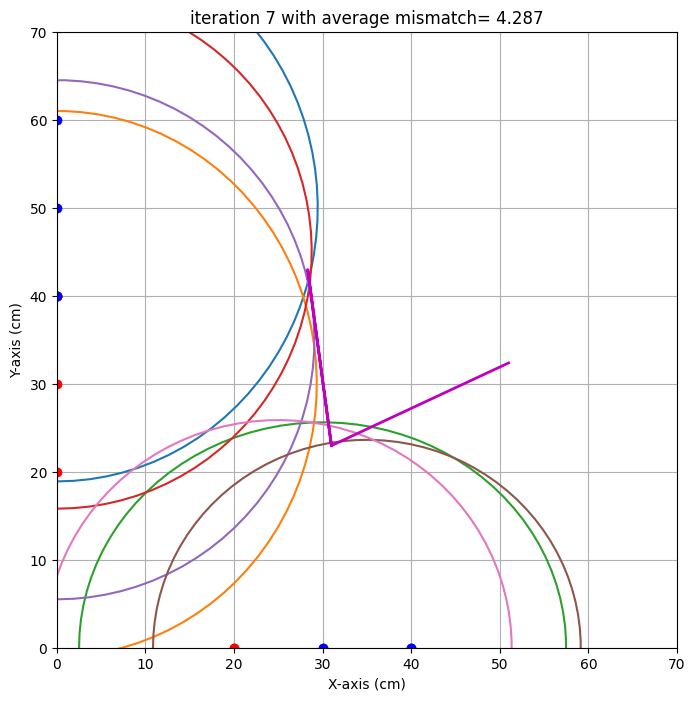

end iteration 7 with average mismatch= 4.287


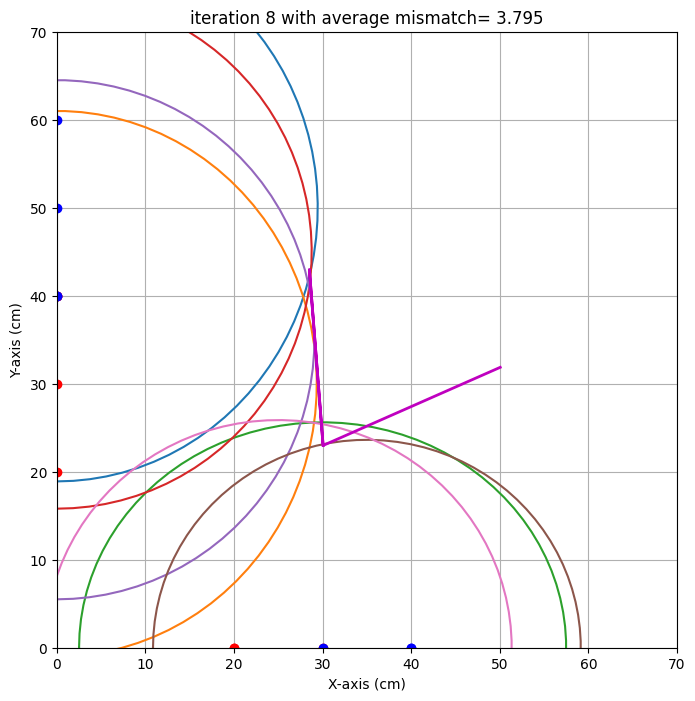

end iteration 8 with average mismatch= 3.795
end iteration 9 with average mismatch= 3.788
end iteration 10 with average mismatch= 3.788
end iteration 11 with average mismatch= 3.629
end iteration 12 with average mismatch= 3.609
end iteration 13 with average mismatch= 3.459
end iteration 14 with average mismatch= 3.446
end iteration 15 with average mismatch= 3.326


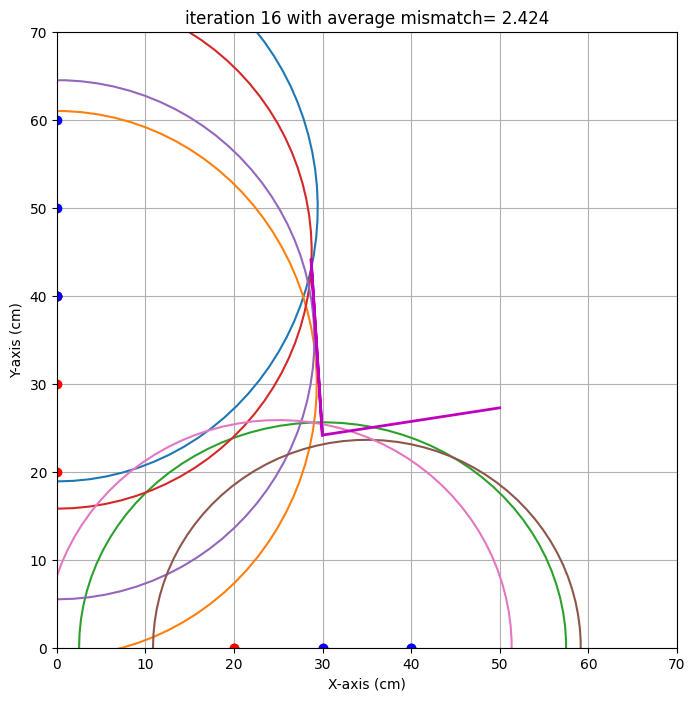

end iteration 16 with average mismatch= 2.424


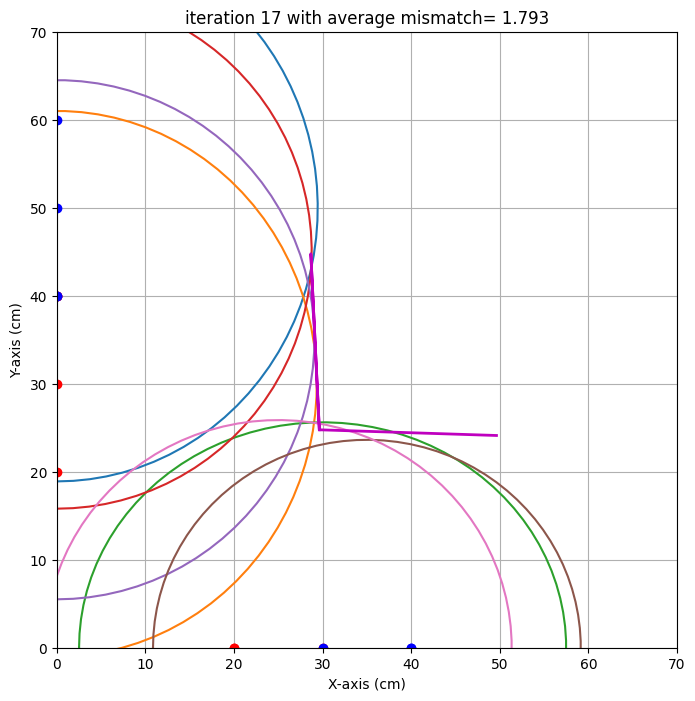

end iteration 17 with average mismatch= 1.793
end iteration 18 with average mismatch= 1.684


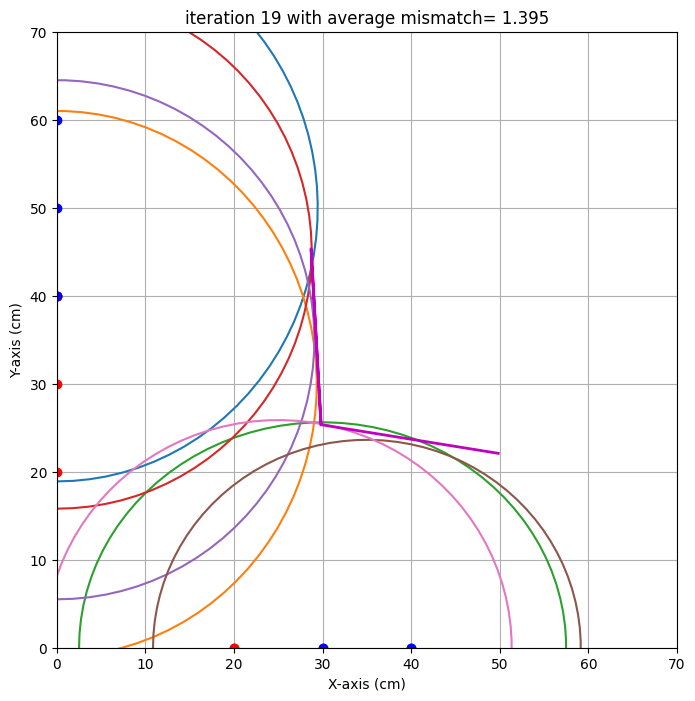

end iteration 19 with average mismatch= 1.395


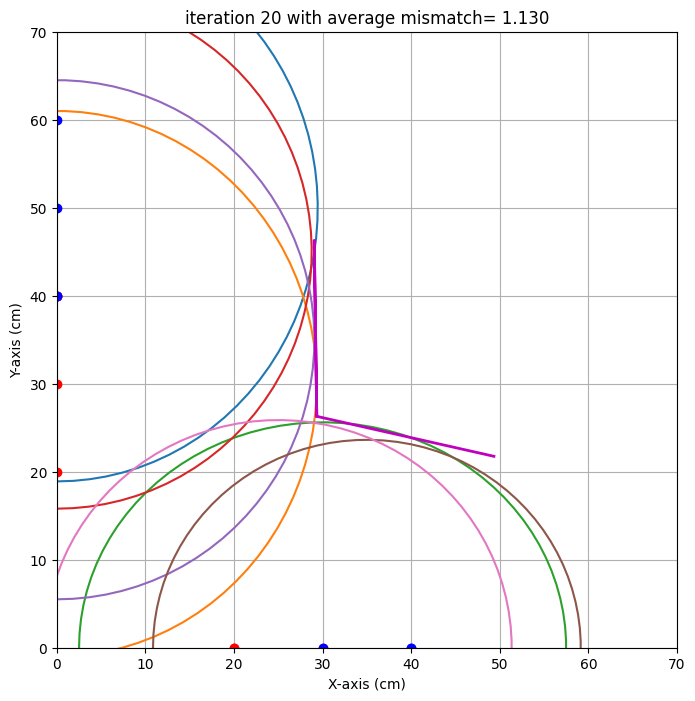

end iteration 20 with average mismatch= 1.130
end iteration 21 with average mismatch= 1.127
end iteration 22 with average mismatch= 1.126
end iteration 23 with average mismatch= 1.126
end iteration 24 with average mismatch= 1.070
end iteration 25 with average mismatch= 1.051
end iteration 26 with average mismatch= 1.048
end iteration 27 with average mismatch= 1.047
end iteration 28 with average mismatch= 1.047
end iteration 29 with average mismatch= 1.047
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.047
###############################################################################
end of iteration  30
Best alpha= -12.74 with uncertainty=   6.87
Best beta =  -1.15 with uncertainty=   1.23
Best x0   =  29.41 with uncertainty=   0.33
Best y0   =  26.52 with uncertainty=   1.17
###############################################################################


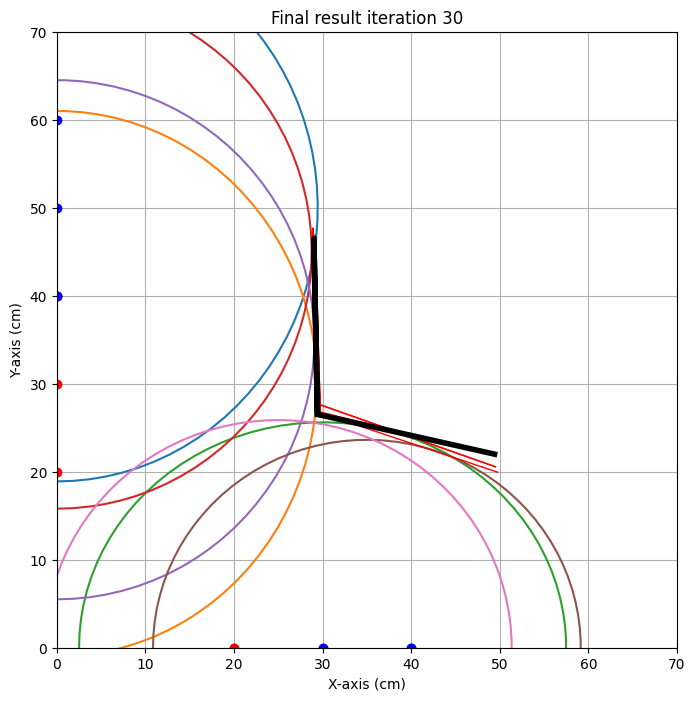

{'alpha': np.float64(-12.743282355612823), 'alpha_eps': np.float64(6.870358354800199), 'beta': np.float64(-1.1479865636825082), 'beta_eps': np.float64(1.2307463624356487), 'x0': np.float64(29.41330846683832), 'x0_eps': np.float64(0.32947117429381123), 'y0': np.float64(26.518913258687082), 'y0_eps': np.float64(1.1661775384160293)}
test locatie 
x0 target is : 29.0. Gevonden waarde: 29.4 cm met een standaardafwijking van 0.3 cm 
y0 target is : 27.0. Gevonden waarde: 26.5 cm met een standaardafwijking van 1.2 cm 
alpha target is : -3.0. Gevonden waarde: -12.7 graden met een standaardafwijking van 6.9 graad 
beta target is : -5.0. Gevonden waarde: -1.1 graden met een standaardafwijking van 1.2 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
#targets = {'test locatie':{
                    #'x0':  41,
                    #'y0':  41,
                    #'alpha' :  -9,
                    #'beta' :  -4
                          #}
            #}
           
targets = {'test locatie':{
                    'x0':  29,
                    'y0':  27,
                    'alpha' : -3 ,
                    'beta' :  -5
                          }
            }

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

#dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                #[0,40,0,60,80.8],
                #[0,20,0,40,ongeldig]
                #[40,0,60,0,78.6],
                #[20,0,40,0,91.1],
                #[0,50,0,60,77.7],
                #[0,45,0,55,78.9],
                #[50,0,60,0,76.9],
                #[45,0,55,0,77.4],
                #[0,55,0,65,80.4],
                #[57,0,63,0,77.1],
                    #])
                #}

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                [0,40,0,60,62.2],
                [0,20,0,40,62.0],
                #[40,0,60,0,ongeldig]
                [20,0,40,0,55.0],
                [0,40,0,50,58.4],
                [0,30,0,40,59.0],
                [30,0,40,0,48.3],
                [20,0,30,0,52.7],

                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.


Eerst zijn drie verschillende algoritmes gemaakt. Vervolgens zijn twee hiervaan getest, waarvan fouten zijn aangepakt, aangepast en verbeterd. Dit is allemaal deel van het synthese onderdeel van de ontwerpcyclus.

<img src="algoritme_avnay_1.jpeg" width="400">
<img src="algoritme_avnay_2.jpeg" width="400">


<img src="algoritme_aren_2.jpeg" width="400">


<img src="algoritme_koen_1.jpeg" width="400">
<img src="algoritme_koen_2.jpeg" width="400">


Vervolgens zijn de ideeen van de voorgaande algoritmes samengevoegd tot een algoritme. Dit algoritme is uiteindelijk gebruikt voor de eindopdracht. Bij de eerste iteratie waren de hoeken onnauwkeurig dus zijn er twee veranderingen gemaakt: als eerst om nog kleinere afstanden tussen de zender en de ontvanger te gebruiken bij de latere metingen, en daarnaast om voor exactere afstanden op een kleine hoek te meten. Binnen dit algoritme worden er eerst metingen gemaakt op (0,40,0,60), (0,20,0,40), (40,0,60,0), (20,0,40,0). Vervolgens is er gekeken naar waar de hits kwamen en daarop gebasseerd is een schets gemaakt. Op basis van die schets zijn er nog meer metingen gemaakt op locaties tussen de voorgaande locaties. 
Figuur: ![Alt](iteratie_kloppend.jpeg)